In [1]:
from tabulate import tabulate
import os
import sys
import torch
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from utils import get_test_images, get_models_results, compare_plot_patches_models, compare_loss_plot

%load_ext autoreload
%autoreload 2

In [2]:
all_images = get_test_images()
print(all_images.keys())
print(all_images[5].keys())
print(all_images[5][2].keys())
print(len(all_images[5][2]['lr']), len(all_images[5][2]['hr']))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dict_keys([5, 14])
dict_keys([2, 3, 4])
dict_keys(['lr', 'hr'])
5 5


## Tablas

In [3]:
models_name = ["nearest", "bilinear", "bicubic"]
set_numbers = [5, 14]
factors= [2, 4]
results1 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results1, headers="keys", tablefmt="fancy_grid", showindex=False))

╒═══════════╤══════════╤════════════════════╤════════════════════╤════════════════════╕
│ Dataset   │   Factor │ nearest            │ bilinear           │ bicubic            │
╞═══════════╪══════════╪════════════════════╪════════════════════╪════════════════════╡
│ Set5      │        2 │ 29.53/0.9018/0.21s │ 30.93/0.9108/0.20s │ 32.63/0.9323/0.31s │
├───────────┼──────────┼────────────────────┼────────────────────┼────────────────────┤
│ Set14     │        2 │ 27.26/0.8494/1.05s │ 27.93/0.8410/1.09s │ 29.22/0.8761/1.31s │
├───────────┼──────────┼────────────────────┼────────────────────┼────────────────────┤
│ Set5      │        4 │ 24.94/0.7448/0.19s │ 26.24/0.7808/0.21s │ 27.31/0.8097/0.21s │
├───────────┼──────────┼────────────────────┼────────────────────┼────────────────────┤
│ Set14     │        4 │ 23.42/0.6585/1.10s │ 24.19/0.6725/1.12s │ 24.89/0.7047/1.17s │
╘═══════════╧══════════╧════════════════════╧════════════════════╧════════════════════╛


In [4]:
models_name = ["bicubic", "SRCNN", "FSRCNN", "FSRCA PS", "FSRCA"]
set_numbers = [5, 14]
factors= [2, 4]
results2 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results2, headers="keys", tablefmt="fancy_grid", showindex=False))

Model weights not found at ../Results/Weights/SRCNN/srcnn_x4.pth.
Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4.pth.
╒═══════════╤══════════╤════════════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Dataset   │   Factor │ bicubic            │ SRCNN              │ FSRCNN             │ FSRCA PS            │ FSRCA              │
╞═══════════╪══════════╪════════════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ Set5      │        2 │ 32.63/0.9323/0.27s │ 34.72/0.9496/1.64s │ 34.51/0.9486/1.30s │ 33.40/0.9395/1.71s  │ 34.61/0.9496/1.18s │
├───────────┼──────────┼────────────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ Set14     │        2 │ 29.22/0.8761/1.38s │ 30.70/0.8987/9.33s │ 30.60/0.8985/5.44s │ 29.85/0.8909/10.22s │ 30.64/0.8999/7.15s │
├───────────┼──────────┼────────────────────┼────────────────────┼──────────

In [5]:
models_name = ["bicubic", "SRCNN", "FSRCNN ft", "FSRCA PS ft", "FSRCA ft"]
set_numbers = [5, 14]
factors= [2, 4]
results3 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results3, headers="keys", tablefmt="fancy_grid", showindex=False))

Model weights not found at ../Results/Weights/SRCNN/srcnn_x4.pth.
Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4_ft.pth.
╒═══════════╤══════════╤════════════════════╤═════════════════════╤════════════════════╤═════════════════════╤════════════════════╕
│ Dataset   │   Factor │ bicubic            │ SRCNN               │ FSRCNN ft          │ FSRCA PS ft         │ FSRCA ft           │
╞═══════════╪══════════╪════════════════════╪═════════════════════╪════════════════════╪═════════════════════╪════════════════════╡
│ Set5      │        2 │ 32.63/0.9323/0.36s │ 34.72/0.9496/2.14s  │ 34.54/0.9488/2.28s │ 33.50/0.9413/2.07s  │ 34.64/0.9498/1.85s │
├───────────┼──────────┼────────────────────┼─────────────────────┼────────────────────┼─────────────────────┼────────────────────┤
│ Set14     │        2 │ 29.22/0.8761/1.87s │ 30.70/0.8987/10.84s │ 30.62/0.8988/6.01s │ 29.94/0.8930/10.17s │ 30.64/0.9000/6.40s │
├───────────┼──────────┼────────────────────┼─────────────────────┼

In [6]:
models_name = ["FSRCNN", "FSRCNN ft", "FSRCA PS", "FSRCA PS ft", "FSRCA", "FSRCA ft"]
set_numbers = [5, 14]
factors= [2, 4]
results4 = get_models_results(models_name, set_numbers, factors, device)
print(tabulate(results4, headers="keys", tablefmt="fancy_grid", showindex=False))

Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4.pth.
Model weights not found at ../Results/Weights/FSRCA_PS/fsrca_ps_x4_ft.pth.
╒═══════════╤══════════╤════════════════════╤════════════════════╤════════════════════╤═════════════════════╤════════════════════╤════════════════════╕
│ Dataset   │   Factor │ FSRCNN             │ FSRCNN ft          │ FSRCA PS           │ FSRCA PS ft         │ FSRCA              │ FSRCA ft           │
╞═══════════╪══════════╪════════════════════╪════════════════════╪════════════════════╪═════════════════════╪════════════════════╪════════════════════╡
│ Set5      │        2 │ 34.51/0.9486/1.49s │ 34.54/0.9488/1.56s │ 33.40/0.9395/1.77s │ 33.50/0.9413/1.87s  │ 34.61/0.9496/1.32s │ 34.64/0.9498/1.30s │
├───────────┼──────────┼────────────────────┼────────────────────┼────────────────────┼─────────────────────┼────────────────────┼────────────────────┤
│ Set14     │        2 │ 30.60/0.8985/5.67s │ 30.62/0.8988/5.78s │ 29.85/0.8909/8.64s │ 29.94

In [7]:
# import pandas as pd

# def print_latex_rows(df,
#                      dataset_col="Dataset",
#                      factor_col="Factor",
#                      method_cols=None):
#     """
#     Imprime para cada fila de `df` una línea LaTeX tipo:
#       \hline
#       \multirow{1}{*}{<Dataset>} & <Factor> & <col1> & <col2> & ... & <coln> \\
#     """
#     if method_cols is None:
#         # Asume que el resto de las columnas son métodos
#         method_cols = [c for c in df.columns
#                        if c not in (dataset_col, factor_col)]

#     for _, row in df.iterrows():
#         # Cabecera de fila
#         print(r"\hline")
#         # Construyo la parte fija: multirow de 1 fila
#         line = r"\multirow{1}{*}{" + f"{row[dataset_col]}" + "}"
#         line += " & " + f"{row[factor_col]}"
#         # Añado cada método
#         for m in method_cols:
#             val = row[m]
#             # Convierte NaN o None a guión
#             if pd.isna(val):
#                 val = "-"
#             line += " & " + str(val)
#         # Final de fila
#         line += r" \\"
#         print(line)
#     # Una última \hline al final de la tabla
#     print(r"\hline")

# # --- Ejemplo de uso ---


# # Entonces:
# print_latex_rows(results4,
#                  dataset_col="Dataset",
#                  factor_col="Factor",
#                  method_cols=None)


## Losses

### Factor 2

#### Sin FT

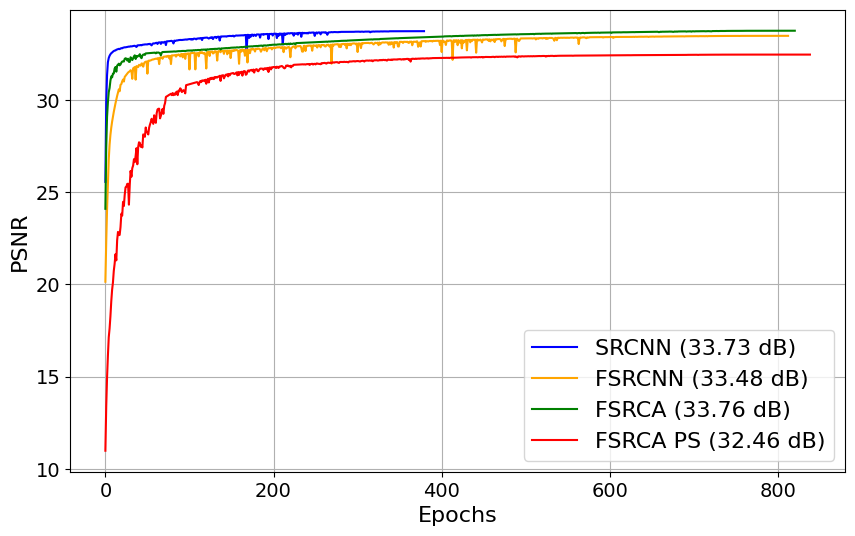

In [8]:
loss = 'psnr_list'
models_names = ["srcnn", "fsrcnn", "fsrca", "fsrca_ps"]
colors = ["blue", "orange", "green", "red"]
fts = [False, False, False, False]
factor = 2
titles = ["SRCNN", "FSRCNN", "FSRCA", "FSRCA PS"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names,fts, factor, titles, colors, loss_label, device=device)

#### Con FT

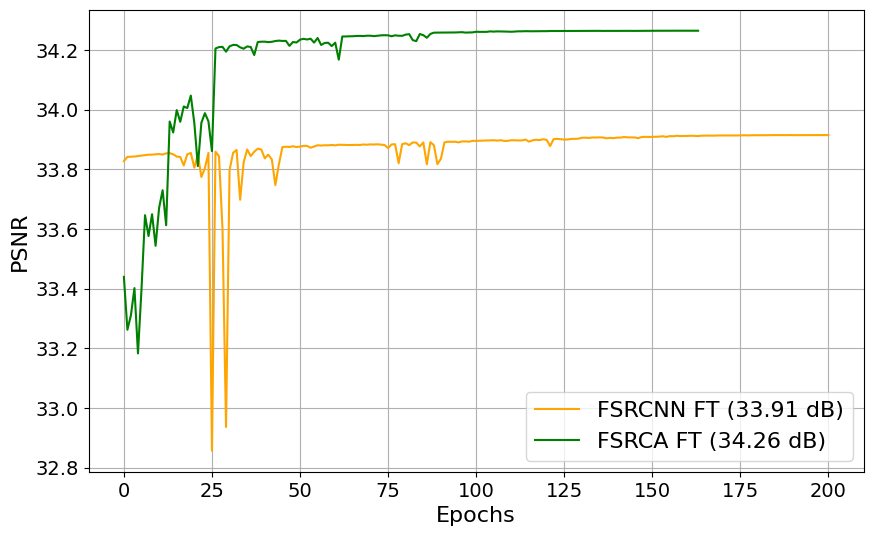

In [9]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca"]
fts = [True, True]
factor = 2
titles = ["FSRCNN FT", "FSRCA FT"]
colors = ["orange", "green"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names, fts, factor, titles, colors, loss_label, device=device)

### Factor 4

#### Sin FT

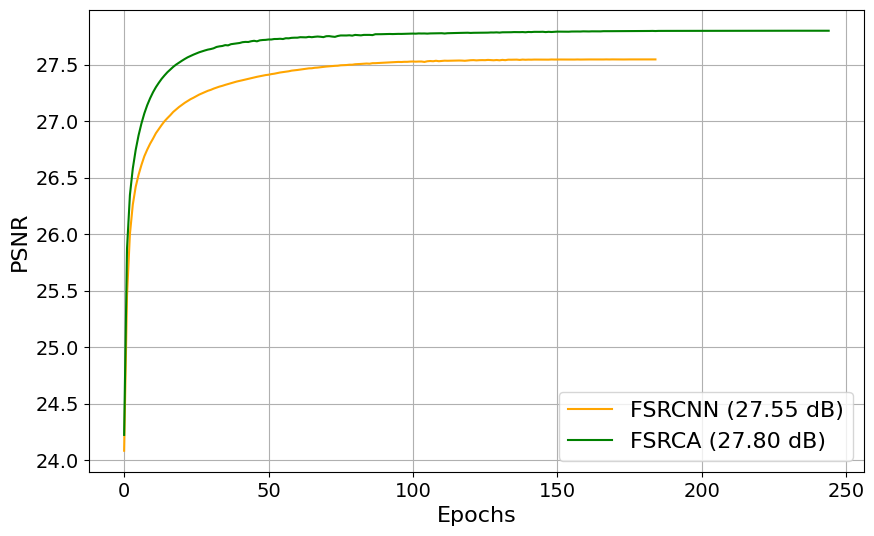

In [10]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca",]
colors = ["orange", "green"]
fts = [False, False]
factor = 4
titles = ["FSRCNN", "FSRCA"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names,fts, factor, titles, colors, loss_label, device=device)

#### Con FT

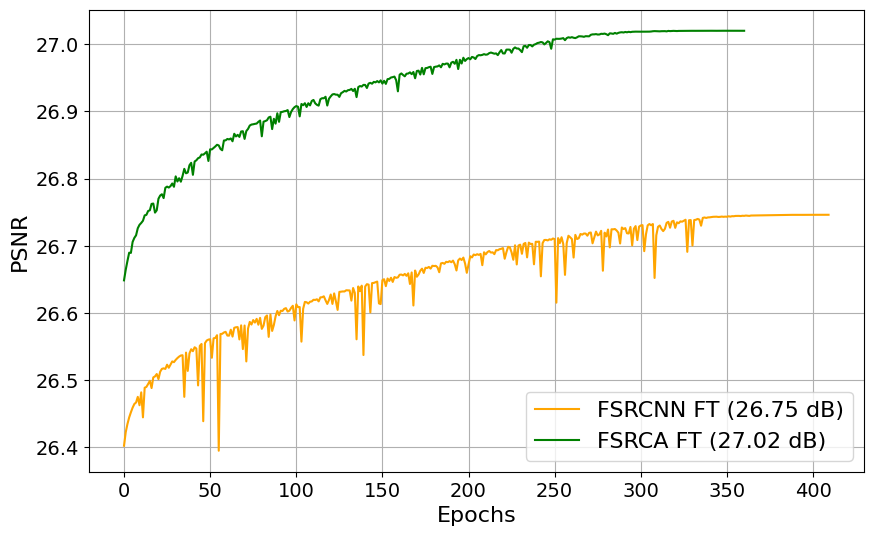

In [11]:
loss = 'psnr_list'
models_names = ["fsrcnn", "fsrca"]
fts = [True, True]
factor = 4
titles = ["FSRCNN FT", "FSRCA FT"]
colors = ["orange", "green"]
loss_label = "PSNR"
compare_loss_plot(loss, models_names, fts, factor, titles, colors, loss_label, device=device)

## Imágenes

In [12]:
zoom_patches_args = {
    'zoom': 2,
    'patch_ratio': 0.25,
    'margin_ratio': 0.05,
    'thickness': 2
}

### Factor 2

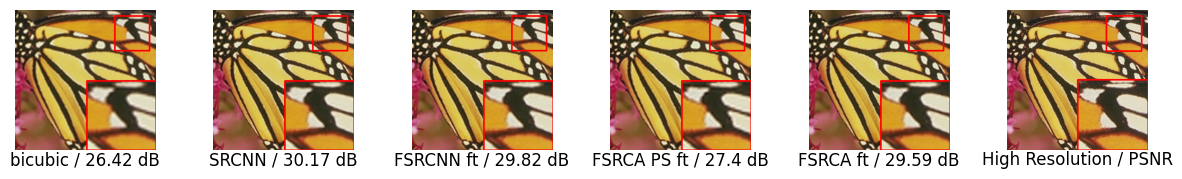

In [13]:
factor = 2
imgs_set = 5
set_dict = all_images[imgs_set][factor]
img_index = 2

models_names = ["bicubic",
                "SRCNN", 
                # "FSRCNN", 
                "FSRCNN ft",
                # "FSRCA",
                "FSRCA PS ft",
                "FSRCA ft"
                ]

compare_plot_patches_models(set_dict, img_index, factor, models_names, zoom_patches_args, device)

### Factor 4

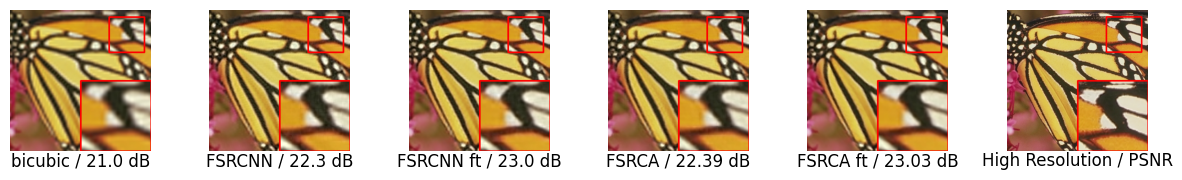

In [15]:
factor = 4
imgs_set = 5
set_dict = all_images[imgs_set][factor]
img_index = 2

models_names = ["bicubic",
                "FSRCNN", 
                "FSRCNN ft",
                "FSRCA",
                "FSRCA ft"
                ]

compare_plot_patches_models(set_dict, img_index, factor, models_names, zoom_patches_args, device)